### Multiclass classification

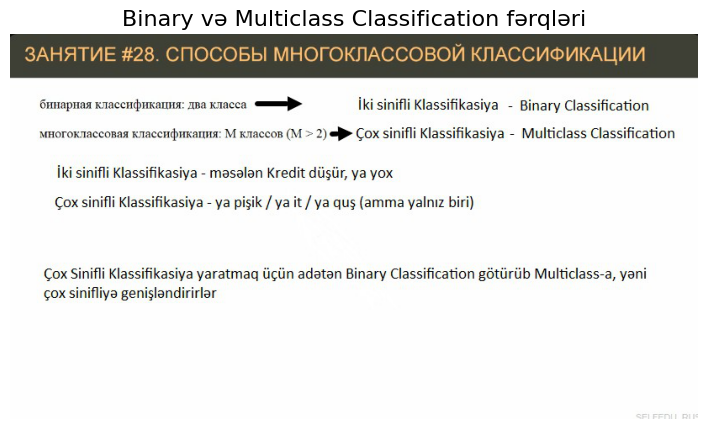

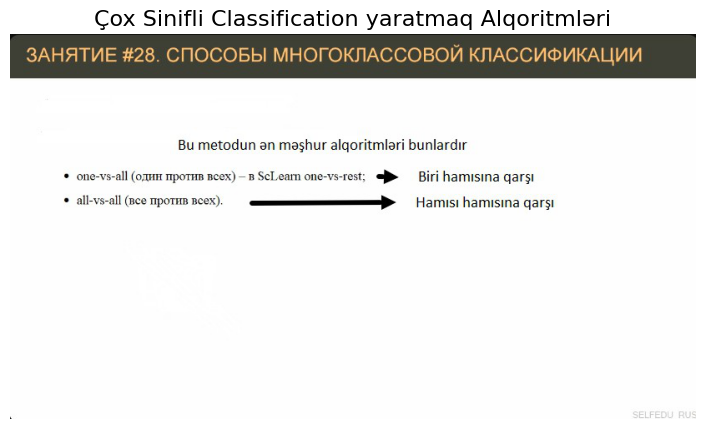

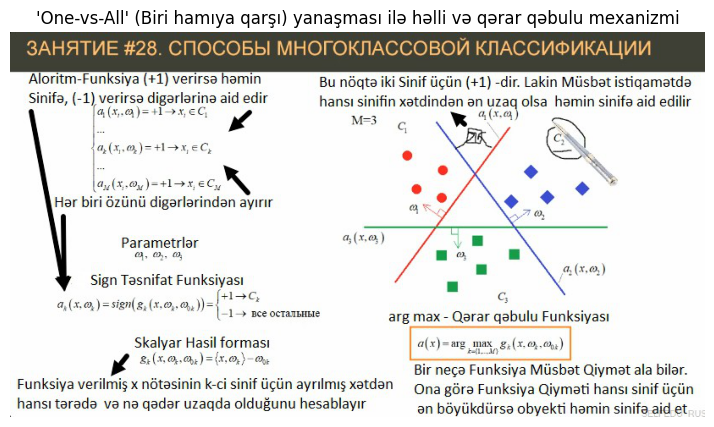

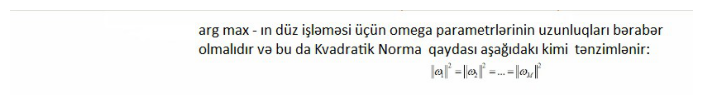

In [7]:
from PIL import Image

# Fayl yolunun əsas hissəsi
base_path = r'C:\Users\dell\Desktop\Selfedu\Pictures\ML_28_'

# Şəkilləri saxlayacağımız siyahı
image_list = []

# 1-dən 5-ə qədər olan şəkilləri dövr ilə açırıq
for i in range(1, 5):  # 1-dən 5-ə qədər
    full_path = f'{base_path}{i}.jpg'  # Fayl yolunu dinamik olaraq yaradırıq
    img = Image.open(full_path)
    image_list.append(img)  # Şəkili siyahıya əlavə edirik

# Nəticə: images siyahısında bütün yüklənmiş şəkillər olacaq

import matplotlib.pyplot as plt

# Şəkilləri göstərin
for i, image in enumerate(image_list):
    if i == 3:
        plt.figure(figsize=(8.8, 4))          
    else:     
        plt.figure(figsize=(25, 5))  # Şəkilin ölçüsü    
        
    if i < 1:
        plt.title("""Binary və Multiclass Classification fərqləri""", size='16')
    elif i < 2:
        plt.title("""Çox Sinifli Classification yaratmaq Alqoritmləri""", size='16')
    elif i < 3:
        plt.title("""'One-vs-All' (Biri hamıya qarşı) yanaşması ilə həlli və qərar qəbulu mexanizmi""", size='12')
    elif i < 4:
        plt.title("""""", size='12')        

    plt.imshow(image)
    plt.axis('off')  # Oxları gizlətmək üçün
    plt.show()

Maşın öyrənməsində təsnifat (classification) obyektləri müəyyən əlamətlərinə görə müvafiq kateqoriyalara (siniflərə) bölmək prosesidir. Bu proses siniflərin sayından asılı olaraq iki əsas qrupa bölünür: **Binary (İkili)** və **Multi-class (Çoxsinifli)**.

---

### 1. Binar (İkili) Təsnifat
Bu, təsnifatın ən sadə formasıdır. Burada yalnız iki mümkün sinif mövcuddur. Model verilən obyekt üçün "bu, yoxsa o?" sualına cavab axtarır.

* **Məntiq:** Giriş məlumatı ($x$) iki etiketdən ($y \in \{0, 1\}$) birinə aid edilir.
* **Həndəsi təsviri:** İkiölçülü fəzada bu, adətən sinifləri ayıran tək bir düz xətt (və ya hipermüstəvi) deməkdir.
* **Nümunə:** E-poçtun spam olub-olmaması; Tibbi testin pozitiv və ya neqativ çıxması.



---

### 2. Multi-class (Çoxsinifli) Təsnifat
Əgər həll edilməli olan məsələdə siniflərin sayı 2-dən çoxdursa ($M > 2$), bu çoxsinifli təsnifat adlanır. Burada hər bir obyekt **yalnız bir** sinfə aid edilə bilər.

* **Məntiq:** Model obyekti bir çox mümkün kateqoriya arasından ən uyğun olanına yerləşdirir.
* **Həndəsi təsviri:** Fəza bir neçə müxtəlif nahiyəyə bölünür və hər bir nahiyə konkret bir sinfi təmsil edir.
* **Nümunə:** Əl yazısı rəqəmlərinin (0, 1, 2...9) tanınması; Şəkillərdəki heyvan növlərinin (it, pişik, quş) təyini.



---

### 3. Aralarındakı Əsas Fərqlər

| Xüsusiyyət | Binar Təsnifat | Multi-class Təsnifat |
| :--- | :--- | :--- |
| **Sinif Sayı** | Cəmi 2 ($y=0$ və ya $y=1$) | 2-dən çox ($y \in \{1, 2, \dots, M\}$) |
| **Qərar Sərhədi** | Tək bir ayırıcı sərhəd bəs edir | Mürəkkəb və çoxsaylı sərhədlər tələb olunur |
| **Çıxış Ehtimalı** | Tək bir ehtimal (məsələn, 0.7) kifayətdir | Hər bir sinif üçün ayrı ehtimal paylanması (Softmax) |

---

### 4. Çoxsinifli Təsnifatın Reallaşdırılması
Bəzi alqoritmlər (məsələn, Qərar Ağacları və ya Neyron Şəbəkələri) təbii olaraq çoxsinifli datalarla işləyə bilir. Lakin xətti modellər (SVM, Logistic Regression) əslində binar təsnifat üçün yaradılıb. Onları çoxsinifli etmək üçün iki əsas yanaşma tətbiq olunur:

#### **One-vs-All (OvA):** Hər bir sinif üçün bir model qurulur. Hər model bir sinfi "digər hamısına" qarşı ayırmağı öyrənir. Sonda ən yüksək xal verən model qalib gəlir.


#### **All-vs-All (AvA):** Hər iki sinif cütlüyü üçün ayrı-ayrı modellər qurulur. Məsələn, 3 sinif varsa: (1 vs 2), (1 vs 3) və (2 vs 3). Sonda ən çox "səs" toplayan sinif seçilir.


---

**Xülasə:** Binar təsnifat təməl kərpicdir, Multi-class isə həmin kərpiclərdən istifadə edərək daha geniş və mürəkkəb qərarlar verən sistemdir. 

Bu giriş izahı sənə metodları daha yaxşı sistemləşdirməyə kömək edir, yoxsa konkret hansısa termin (məsələn, "decision boundary" və ya "probability threshold") qaranlıq qaldı?

Daha aydın və vizual bir yanaşma ilə izah edək. Təsnifat (classification) — modelin girişdəki məlumatı hansısa "qutuya" (kateqoriyaya) aid etməsi prosesidir.

### 1. Binar (İkili) Təsnifat: "Sualın yalnız iki cavabı var"
Təsəvvür et ki, sənə bir meyvə verilir və sən yalnız onun **"alma"** olub-olmadığını deməlisən. Cavab ya "Hə" (1), ya da "Yox" (0) ola bilər.

* **Necə işləyir:** Fəzada bir düz xətt çəkilir. Xəttin bir tərəfi "Hə", digər tərəfi "Yox" zonasıdır.
* **Nümunə:** Bank əməliyyatı fırıldaqçılıqdır (Fraud), yoxsa normal (Normal)?



---

### 2. Multi-class (Çoxsinifli) Təsnifat: "Seçim çoxdur"
İndi isə qarşında bir səbət meyvə var: **alma, armud, banan**. Sən meyvəni götürüb bu üç qutudan birinə qoymalısan. Obyekt mütləq **yalnız bir** sinfə aid olmalıdır.

* **Fərq:** Binar təsnifatda biz "alma yoxsa alma deyil?" deyirdik. Çoxsiniflidə isə "alma, armud, yoxsa banan?" deyirik.



---

### 3. Bu problemi necə həll edirik? (Strategiyalar)

Əlimizdə yalnız binar (iki tərəfli) seçim edə bilən sadə bir alqoritm (məsələn, SVM) varsa, biz onu çoxsinifli etmək üçün "hiylə" işlədirik:

#### A. One-vs-All (Biri hamıya qarşı)
Modeli hər sinif üçün ayrıca öyrədirik:
1.  **Model 1:** Alma vs (Armud + Banan) $\to$ "Bu almadır?"
2.  **Model 2:** Armud vs (Alma + Banan) $\to$ "Bu armuddur?"
3.  **Model 3:** Banan vs (Alma + Armud) $\to$ "Bu banandır?"
**Qərar:** Hansı model daha "əminliklə" (yüksək balla) "Hə" deyirsə, qalib odur.



#### B. All-vs-All (Hamı hamıya qarşı)
Burada sinifləri cüt-cüt döyüşdürürük (turnir sistemi kimi):
1.  **Döyüş 1:** Alma vs Armud
2.  **Döyüş 2:** Alma vs Banan
3.  **Döyüş 3:** Armud vs Banan
**Qərar:** Hər döyüşün qalibi 1 xal alır. Sonda ən çox "xal" (səs) toplayan meyvə qalib elan olunur.



---

### 4. Xülasə: Hansı daha yaxşıdır?
* **Binar:** Ən bəsitidir, fundamentdir.
* **One-vs-All:** Sinif sayı çoxdursa sürətlidir, amma data balanssız ola bilər (məsələn, 1 alma vs 1000 digər meyvə).
* **All-vs-All:** Daha dəqiq sərhədlər qurur, amma sinif sayı artdıqca (məsələn, 100 sinif olsa) model sayı həddindən çox olur (4950 model!).

İndi bu izah daha aydın oldu, yoxsa hansısa hissəni (məsələn, riyazi tərəfini) daha da sadələşdirim?

Çoxsinifli təsnifat (Multi-class classification) maşın öyrənməsinin ən fundamental sahələrindən biridir. Gəl, hər şeyi təməldən başlayaraq sistemli şəkildə izah edək.

---

## 1. Binar (İkili) Təsnifat Nədir?
Binar təsnifat ən sadə modeldir. Burada model yalnız iki mümkün sinifdən birini seçir. Riyazi olaraq çıxış $y \in \{0, 1\}$ və ya $y \in \{-1, +1\}$ şəklində olur.

* **Məntiq:** Sual həmişə "Hə" və ya "Yox" formasındadır.
* **Nümunə:** E-poçtun spam olub-olmaması, xəstənin sağlam və ya xəstə olması.



---

## 2. Multi-class (Çoxsinifli) Təsnifat Nədir?
Çoxsinifli təsnifatda mümkün çıxışların sayı 2-dən çoxdur ($M > 2$). Obyekt yalnız **bir** sinfə aid edilə bilər.

* **Məntiq:** "Bu obyekt hansı kateqoriyaya aiddir?" sualına cavab axtarılır.
* **Nümunə:** Əl yazısı ilə yazılmış rəqəmlərin tanınması (0-dan 9-a qədər 10 sinif), meyvələrin növlərə (alma, armud, banan) ayrılması.



---

## 3. Binar və Multi-class Arasındakı Fərqlər

| Xüsusiyyət | Binar Təsnifat | Multi-class Təsnifat |
| :--- | :--- | :--- |
| **Sinif sayı** | Dəqiq 2 sinif | 2-dən çox sinif ($M > 2$) |
| **Sərhəd** | Bir dənə ayrıcı xətt (hipermüstəvi) | Birdən çox ayrıcı xətt və ya mürəkkəb sərhədlər |
| **Alqoritmlər** | Logistic Regression, SVM (orijinal halı) | Random Forest, Naive Bayes, Neural Networks |
| **Yanaşma** | Birbaşa həll olunur | Tez-tez binar modellərin kombinasiyası ilə həll olunur (OvA, AvA) |

---

## 4. Multi-class Təsnifat Metodları
Bir çox alqoritm təbiəti etibarilə binar təsnifat üçün nəzərdə tutulub (məsələn, SVM). Onları çoxsinifli məsələlərdə tətbiq etmək üçün iki əsas strateji yanaşma istifadə olunur:

### A. One-vs-All (OvA) / One-vs-Rest
* Hər sinif üçün bir model qurulur.
* Model həmin sinfi yerdə qalan bütün siniflərin cəminə qarşı öyrənir.
* **M sinif üçün M sayda model tələb olunur.**

### B. All-vs-All (AvA) / One-vs-One
* Hər sinif cütlüyü üçün ($C_1$ vs $C_2$, $C_1$ vs $C_3$ və s.) ayrı model qurulur.
* Sonda "səsvermə" yolu ilə qalib seçilir.
* **M sinif üçün $\frac{M(M-1)}{2}$ sayda model tələb olunur.**

---

## 5. Xülasə
Multi-class təsnifat real dünya problemlərini (obyektlərin tanınması, dil təyini və s.) həll etmək üçün mütləqdir. Əgər alqoritm təbii olaraq çoxsinifli deyilsə (məsələn, xətti təsnifatçılar), biz yuxarıda müzakirə etdiyimiz OvA və ya AvA metodları ilə onları çoxsinifli məsələyə uyğunlaşdırırıq.

Səncə, siniflərin sayı çox (məsələn, 1000 sinif) olduqda hansı metod (OvA yoxsa AvA) hesablama resursları baxımından daha çətin olar?

#### **One-vs-All (OvA) method - (Biri hamıya qarşı) yanaşması ilə həll və Qərar qəbulu mexanizmi**

#### **1. Binary(İkili) Təsnifat Sistemi**
- **$M$ sayda sinif üçün qurulmuş binar qaydaları ifadə edir:**
$$\begin{cases} a_1(x, \omega_1) = +1 \to x \in C_1 \\ \dots \\ a_k(x, \omega_k) = +1 \to x \in C_k \\ \dots \\ a_M(x, \omega_M) = +1 \to x \in C_M \end{cases}$$
* **İzahı:** **Bu sistem hər bir sinif ($C_k$) üçün ayrıca bir qayda müəyyən edir. Sistemdəki hər bir sətir Alqoritm-Funskiya özünü digər siniflərdən ayırır. Yəni əgər $+1$ nəticə verirsə həmin sinifə aiddir, mənfi nəticə verərsa qalan digərlərinə aiddir.**
- **Məsələn, birinci sətir deyir ki, əgər $a_1$ funksiyası müsbət $+1$ nəticə verərsə, onda obyekt ($x$) birinci sinfə ($C_1$) aiddir, əks halda digərlərinə:**
    - **Bu, hər bir sinfi "özü və özü olmayanlar" şəklində ayırmağın riyazi təsviridir.**

<br>

#### **2 Çəki (əmsalları) vektorlarıdır (Weight vectors)**
$$\omega_1, \omega_2, \omega_3$$

- **Hər bir sinfə məxsus ayrıcı düz xətlərin fəzadakı istiqamətini və meyilliyini müəyyən edən çəki vektorlarıdır (weight vectors). Qrafikdə onlar xətlərə perpendikulyar olan oxlar kimi təsvir olunur və həmin sinfin yerləşdiyi "müsbət" tərəfi göstərirlər. Riyazi olaraq, giriş məlumatlarının ($x$) hansı sinfə daha yaxın olduğunu hesablamaq üçün istifadə olunan əsas parametr əmsallarıdır.**

<br>

#### **3. Sign Təsnifat Funksiyası (Binary Classifier) - İkili Qərar Funksiyası**
$$a_k(x, \omega_k) = \text{sign}(g_k(x, \omega_k, \omega_{0k})) = \begin{cases} +1 \to C_k \\ -1 \to \text{все остальные} \end{cases}$$
* **İzahı:** **Burada $a_k$ funksiyası "sign" (işarə) funksiyasıdır:** 
    * **Əgər daxildəki $g_k$ hesablaması müsbətdirsə, nəticə $+1$ olur və obyekt $C_k$ sinfinə aid edilir.**
    * **Əgər nəticə mənfidirsə ($-1$), bu o deməkdir ki, obyekt həmin konkret sinfə aid deyil ("все остальные" - yəni qalan digər bütün siniflər).**

<br>

#### **4. Xətti Diskriminant Funksiyası**
$$g_k(x, \omega_k, \omega_{0k}) = \langle x, \omega_k \rangle - \omega_{0k}$$
* **İzahı (1) :** **Bu, modelin "nüvəsi"dir. $\langle x, \omega_k \rangle$ xüsusiyyətlər vektoru ($x$) ilə çəki vektorunun ($\omega_k$) skalyar hasilidir. $\omega_{0k}$ isə xəttin yerini tənzimləyən sərbəst həddir. Bu düstur obyektin ayrıcı xətdən (hipermüstəvidən) nə qədər uzaqda olduğunu rəqəmsal olaraq hesablayır.**

<br>

* **İzahı (2):** **Burada $\langle x, \omega_k \rangle$ skalyar hasili (proyeksiyanı), $\omega_k$ çəki vektorunu (hipermüstəvinin normalı), $\omega_{0k}$ isə kəsmə nöqtəsini (bias) ifadə edir. Funksiya verilmiş $x$ nöqtəsinin $k$-cı sinif üçün ayrılmış xətdən hansı tərəfdə və nə qədər uzaqda olduğunu hesablayır.** 

<br>

#### **5. Qərar Qəbulu (Argmax Qaydası)**
$$a(x) = \arg \max_{k=\{1, \dots, M\}} g_k(x, \omega_k, \omega_{0k})$$
* **İzahı (1):** **Çoxsinifli təsnifatda bəzən bir obyekt üçün bir neçə funksiya "müsbət" cavab verə bilər. Bu düstur deyir:**
    - "$g_k$ **qiyməti hansı sinif üçün ən böyükdürsə (maksimumdursa), obyekti həmin sinfə aid et". Bu, modelin ən əmin olduğu sinfi seçməsi deməkdir.** 

<br>

* **İzahı (2):** **"One-vs-All" yanaşmasında obyektin hansı sinfə aid olduğunu təyin etmək üçün bütün $g_k$ funksiyaları hesablanır. Hansı funksiya maksimum qiymət (ən böyük inam intervalı) verirsə, obyekt həmin $k$ indeksli sinfə aid edilir.**

<br>

#### **6. Qrafikin İzahı**

- **Qrafikdə $M=3$ (üç sinif: $C_1, C_2, C_3$) üçün fəzanın bölünməsi təsvir olunub:**

    * **Rəngli Nöqtələr:** **Müvafiq siniflərin təlim nümunələridir (Qırmızı - $C_1$, Mavi - $C_2$, Yaşıl - $C_3$).**
    * **Düz Xətlər (Hipermüstəvilər):**  
        * $a_1(x, \omega_1)$ **(Qırmızı xətt): $C_1$ sinfini digərlərindən ayırır.**
        * $a_2(x, \omega_2)$ **(Göy xətt): $C_2$ sinfini digərlərindən ayırır.**
        * $a_3(x, \omega_3)$ **(Yaşıl xətt): $C_3$ sinfini digərlərindən ayırır.**
    * **Normal Vektorlar ($\omega_1, \omega_2, \omega_3$):** **Xətlərə perpendikulyar olan oxlar müsbət yarımfəzanı (həmin sinfə aid olan zonanı) göstərir.**

#### **Qrafikdəki Problem: "Qeyri-müəyyənlik Zonası"**
- **Qrafikin mərkəzində xətlərin kəsişdiyi yerdə boş bir üçbucaq sahə yaranır. "One-vs-All" metodunda bu zona problemlidir, çünki burada birdən çox təsnifatçı eyni anda $+1$ (müsbət) cavabı verə bilər və ya hamısı mənfi ola bilər. Məhz bu səbəbdən yuxarıdakı $'\arg \max'$ düsturu tətbiq olunur:**
    - **yəni obyekt o sinfə aid edilir ki, həmin sinfin xəttindən müsbət istiqamətdə ən uzaq məsafədə olsun.**

### **One-vs-All Praktik izahı**

- **One-vs-All (və ya One-vs-Rest) yanaşmasında prosesin necə işlədiyini və o "tək qalib"in necə seçildiyini riyazi və məntiqi olaraq belə izah edə bilərik:**

#### **1. Modellərin Qurulması (Sualın qoyuluşu)**
- **Sizin nümunənizdə 3 sinif var: Pişik, İt və Tülkü. Sistem hər sinif üçün ayrı bir binar (ikiqat) təsnifatçı hazırlayır. Hər bir modelin sualı belədir:**

    * **Model 1:** **Bu pişikdirmi? (Bəli / Xeyr)**
    * **Model 2:** **Bu itdirmi? (Bəli / Xeyr)**
    * **Model 3:** **Bu tülküdürmü? (Bəli / Xeyr)**

> **Burada "Xeyr" dedikdə model digər bütün sinifləri bir "kütlə" (rest) kimi görür. Məsələn, Model 1 üçün "Xeyr" həm it, həm də tülkü deməkdir.**

<br>

#### **2. Qərar Vermə Mexanizmi (Ehtimallar)**
- **Bu modellər sadəcə "hə/yox" demirlər. Həm də Onlar əslində bir ehtimal balı (confidence score) verirlər. Məsələn, yeni bir şəkil daxil etdikdə modellər aşağıdakı nəticələri çıxara bilər:**
    * **Model 1 (Pişik):** **0.85 (85% əminliklə pişikdir)**
    * **Model 2 (İt):** **0.10 (10% əminliklə itdir)**
    * **Model 3 (Tülkü):** **0.05 (5% əminliklə tülküdür)**

<br>

#### **3. Nəticə Necə Seçilir?**
- **Sistem bütün modellərdən gələn balları müqayisə edir və maksimum balı olanı qalib elan edir. Riyazi olaraq bu, $argmax$ funksiyası ilə ifadə olunur:**

    $$\hat{y} = \text{argmax}_{i \in \{1 \dots K\}} f_i(x)$$

    - **Yəni, $i$ sinifləri arasında ən yüksək funksiya nəticəsini ($f_i$) verən sinif seçilir. Sizin nümunədə 0.85 ən yüksək olduğu üçün sistem deyir: "Bu, pişikdir"**.

<br>

#### **4. Problem yarana bilərmi?**
- **Bəzən "qeyri-müəyyənlik" zonaları yarana bilər. Məsələn:**
    * **Pişik modeli: 0.45**
    * **Tülkü modeli: 0.42**
    * **İt modeli: 0.13**
    - **Burada fərq az olsa da, yenə də 0.45 ilə "Pişik" seçiləcək. Lakin bu, modelin tam əmin olmadığını göstərir.**

<br>

 - **Xülasə:** 
> **Hər model özünü digər "hamısından" ayırmağa çalışır (məsələn, pişik vs. qalanları). Axırda isə kimin səsi daha gur çıxırsa (ehtimalı yüksəkdirsə), onun etiketi son nəticə kimi qəbul edilir.**


#### **One-vs-All (OvA) yanaşması sadə olsa da, Mürəkkəb məsələlərdə bəzi ciddi mənfi cəhətləri var**

* **1. Siniflərin Disbalansı (Unbalanced Classes):** **Bu, ən böyük problemdir. Məsələn, 10 sinifli bir məsələdə bir sinfi ($C_1$) digər 9 sinfə qarşı təlim etdikdə, "digərləri" qrupu data baxımından çox üstün olur. Bu da modelin çoxluq təşkil edən tərəfə meyillənməsinə səbəb olur.**
* **2. Qeyri-müəyyənlik Zonaları (Ambiguity Zones):** **Sənin göndərdiyin qrafikin mərkəzindəki boşluq kimi, elə zonalar yaranır ki, orada ya birdən çox təsnifatçı "müsbət" cavab verir, ya da hamısı "mənfi". Bu zaman model hansı sinfi seçəcəyinə dair dəqiq həndəsi sərhədə malik olmur (buna görə mütləq $\arg \max$ hesablamaq lazım gəlir).**
* **3. Ölçək Problemi (Scale Inconsistency):** **Hər bir Binaty Təsnifat Funksiyası ($g_1, g_2, \dots$) bir-birindən müstəqil öyrədilir. Bu o demekdir ki, $g_1$ funksiyasının çıxardığı ehtimal və ya məsafə qiyməti ilə $g_2$-nin qiyməti eyni şkalada olmaya bilər. Bu da onların nəticələrini bir-biri ilə müqayisə etməyi (hansı daha böyükdür sualını) çətinləşdirir.**

- **Xülasə:**
> **siniflərin sayı çoxaldıqca bu model "data disbalansı" və "qərar vermə qeyri-müəyyənliyi" səbəbindən effektivliyini itirə bilir.**

#### **All-vs-All (AvA) method - (Hamı hamıya qarşı) yanaşması ilə həll və Qərar qəbulu mexanizmi**

> **All-vs-All (AvA) və ya One-vs-One strategiyası çoxsinifli təsnifat məsələlərini həll etmək üçün istifadə olunan digər mühüm yanaşmadır. Bu metodda hər bir sinif cütlüyü üçün ayrıca model qurulur.**


#### **1. Cədvəlin İzahı**
- **Cədvəl bütün mümkün sinif cütlükləri arasındakı qarşıdurmaları göstərir:**
    * **Sətirlər və Sütunlar:** **1-dən $M$-ə qədər olan rəqəmlər sinifləri təmsil edir.**
    * **$a_{ij}(x, \omega_{ij})$:** **Bu, $i$-ci siniflə $j$-ci sinfi bir-birindən ayıran binar təsnifatçıdır. Məsələn, $a_{12}$ yalnız 1-ci və 2-ci siniflərin datası üzərində öyrədilir:**
        - **Yəni $a_{12}$  Modeli 1-ci və 2-ci sinifləri bir birindən ayıran Binary Alqoritmik Funksiyasıdır.**
    * **Diaqonal (0-lar):** **Bir sinfin özü ilə qarşıdurması mənasız olduğu üçün diaqonal elementlər sıfırdır.**

<br>

#### **2 İkili Təsnifat Qaydası:**
$$a_{ij}(x, \omega_{ij}) = \begin{cases} +1, & x \in C_i \\ -1, & x \in C_j \end{cases}$$
* **Nədir:** **Bu funksiya yalnız iki konkret sinfi ($C_i$ və $C_j$) müqayisə edir. Digər bütün siniflər bu hesablamada iştirak etmir. Əgər nəticə $+1$-dirsə $i$ sinfi, $-1$-dirsə $j$ sinfi qalib sayılır.**

<br>

#### **3. Antisimetriklik Xassəsi:**
$$a_{ij}(x, \omega_{ij}) = -a_{ji}(x, \omega_{ji})$$
* **Nədir:** **Bu o deməkdir ki, "i-nin j-yə qarşı" təsnifatçısı, "j-nin i-yə qarşı" təsnifatçısının tam əksidir. Bu, hesablama resurslarına qənaət etmək üçün istifadə olunur:**
    - **cədvəlin yalnız bir tərəfini (məsələn, yuxarı üçbucağı) hesablamaq kifayətdir.**

<br>

#### **4. Təsnifatçıların Sayı:**
$$\frac{M \cdot (M - 1)}{2}$$
* **Nədir:** **Bu düstur modeldə cəmi neçə binar təsnifatçının öyrədilməli olduğunu göstərir. Məsələn, 4 sinif varsa, cəmi $\frac{4 \times 3}{2} = 6$ dənə model qurulmalıdır.**

<br>

- **Bu düstur riyaziyyatda (xüsusilə kombinatorikada) $M$ elementdən 2-sinin seçilməsi kombinasiyalarının sayını ifadə edir.**

- **Daha sadə dildə desək, bu düstur aşağıdakı suallara cavab verir:**
    * **Cütlüklərin sayı:** $M$ **sayda obyekt arasından neçə fərqli cütlük (ikili qrup) düzəltmək olar?**
    * **Görüşlərin sayı:** **Əgər bir otaqda $M$ nəfər varsa və hər kəs bir-biri ilə əl sıxışmalıdırsa, cəmi neçə əl sıxışma baş verər?**
    * **Oyunların sayı:** $M$ **komandanın iştirak etdiyi turnirdə hər komanda digəri ilə bir dəfə oynayırsa, cəmi neçə oyun keçirilər?**

<br>

- **Riyaziyyatda bu, kombinasiya düsturunun xüsusi halıdır:**
    $$C_M^2 = \binom{M}{2} = \frac{M!}{2!(M-2)!} = \frac{M \cdot (M - 1)}{2}$$

    - **Təsnifat məsələsində bu düstur "M" sayda sinfi bir-biri ilə iki-iki müqayisə etmək üçün neçə dənə model qurmaq lazımdır?" sualına cavab verir.**

- **Nümunə:**
    - **Əgər $M = 4$ sinfin varsa:**
    $$\frac{4 \cdot (4 - 1)}{2} = \frac{4 \cdot 3}{2} = 6$$
    - **Deməli, bu 4 sinif üçün cəmi 6 fərqli binar (ikili) təsnifatçı ($a_{12}, a_{13}, a_{14}, a_{23}, a_{24}, a_{34}$) qurmalısan.**




<br>

#### **5. Yekun Qərar Mexanizmi (Argmax)**

$$a(x) = \arg \max_{k=1, \dots, M} \sum_{i=1}^{M} \sum_{\substack{j=1 \\ j \neq i}}^{M} [a_{ij}(x) = k]$$

**Geniş İzahı (Necə işləyir?):**
- **1.  Səsvermə: Yeni bir $x$ obyekti daxil olduqda, o, cədvəldəki bütün $\frac{M(M-1)}{2}$ sayda təsnifatçıya təqdim olunur.**
- **2.  Səslərin Toplanması: Hər bir təsnifatçı bir qalib seçir. Məsələn, $a_{12}$ deyir "1-ci sinif qalibdir", $a_{13}$ deyir "1-ci sinif qalibdir", $a_{23}$ deyir "3-cü sinif qalibdir".**
- **3.  İndikator Funksiyası: $[a_{ij}(x) = k]$ ifadəsi bir yoxlamadır. Əgər $a_{ij}$ təsnifatçısı qalib kimi $k$ sinfini seçibsə, bu ifadə $1$ (bir səs) qiymətini alır, əks halda $0$ olur.**
- **4.  Cəmləmə: Hər bir sinif ($k$) üçün ona verilən bütün səslər toplanır.**
- **5.  Qalibin Elanı (Argmax): Sonda ən çox səs toplayan sinif ($k$) obyektin yekun sinfi kimi qəbul edilir.**

<br>

- **Nümunə:** **3 sinifli məsələdə:**
    * $a_{12} \to$ **1-ci sinifə səs verdi.**
    * $a_{13} \to$ **1-ci sinifə səs verdi.**
    * $a_{23} \to$ **2-ci sinifə səs verdi.**
    * **Nəticə: 1-ci sinif 2 səs, 2-ci sinif 1 səs, 3-cü sinif 0 səs topladı. Qalib: 1-ci sinif**.

<br>

- **Niyə All-vs-All?**
> **Bu metod "One-vs-All"dakı disbalans problemini həll edir, çünki hər model yalnız iki sinfi müqayisə edir və datalar daha balanslı olur. Lakin sinif sayı ($M$) çox olduqda model sayı sürətlə artır.**

### **All-vs-All Praktik izahı**

> **One-vs-One (və ya bəzən deyildiyi kimi All-vs-All) yanaşması "One-vs-All"dan fərqli olaraq, hər kəsi kütləvi şəkildə qarşılaşdırmır. Bu üsulda hər bir sinif cütlüyü üçün ayrıca bir "duel" (təkbətək döyüş) təşkil olunur.**

- **Pişik, İt və Tülkü nümunəniz üzərindən bu prosesin necə işlədiyini addım-addım izahı:**

#### **1. Modellərin Qurulması (Duellər)**
- **Bu yanaşmada hər mümkün cütlük üçün bir model qurulur. Kombinatorika düsturu ilə desək, $n$ sayda sinif üçün $\frac{n(n-1)}{2}$ sayda model tələb olunur. Sizin 3 heyvanınız üçün $3 \times (3-1) / 2 = 3$ model qurulacaq:**
    * **Model 1:** **Pişik vs. İt (Tülkülər bu təlimdə iştirak etmir)**
    * **Model 2:** **Pişik vs. Tülkü (İtlər iştirak etmir)**
    * **Model 3:** **İt vs. Tülkü (Pişiklər iştirak etmir)**

<br>

#### **2. Sualın Qoyuluşu**
- **Burada sual "Bu pişikdir, yoxsa deyil?" kimi qoyulmur. Sual konkret iki seçim arasındadır:**
    * **"Bu pişikdir, yoxsa itdir?"**
    * **"Bu pişikdir, yoxsa tülküdür?"**
    * **"Bu itdir, yoxsa tülküdür?"**

<br>

#### **3. Səsvermə Mexanizmi (Voting)**
- **Yeni bir şəkil sistemə daxil edildikdə, bütün modellər öz qərarlarını verir. Hər modelin qalibi 1 xal (səs) qazanır:**
    - **1.  Model 1 (Pişik vs. İt): Şəkilə baxır və deyir: "Məncə bu Pişikdir". (Pişik: 1 xal, İt: 0 xal)**
    - **2.  Model 2 (Pişik vs. Tülkü): Baxır və deyir: "Məncə bu Pişikdir". (Pişik: 2 xal, Tülkü: 0 xal)**
    - **3.  Model 3 (İt vs. Tülkü): Baxır və deyir: "Bu ikisi arasında qalsam, Tülkü deyərdim". (Tülkü: 1 xal, İt: 0 xal)**

<br>

#### **4. Qalibin Seçilməsi**
- **Sonda xallar toplanır:**
    * **Pişik:** **2 səs**
    * **Tülkü:** **1 səs**
    * **İt:** **0 səs**
    
    <br>
    
    **Nəticə:** 
    - **Ən çox səs toplayan sinif (Pişik) qalib elan olunur.**

<br>

#### **One-vs-All ilə One-vs-One arasındakı fərq:**

| Xüsusiyyət | One-vs-All (OvR) | One-vs-One (OvO) |
| :--- | :--- | :--- |
| **Model sayı** | **Sinif sayı qədər** ($n$) | **Daha çox** ($\frac{n(n-1)}{2}$) |
| **Hər modelin sualı** | **"X"dir, yoxsa "X" deyil?** | **"X"dir, yoxsa "Y"?** |
| **Hesablama** | **Böyük verilənlərdə sürətlidir.** | **Sinif sayı çoxaldıqca model sayı kəskin artır.** |
| **Dəqiqlik** | **"Pişik deyil" kütləsi qarışıq ola bilər.** | **Hər model daha spesifik bir fərqi öyrənir.** |

> **SVM (Support Vector Machines) kimi alqoritmlər adətən One-vs-One tərəfdarıdır, çünki iki konkret qrup arasındakı sərhədi (margin) tapmaq, bir qrupu qalan bütün dumanlı kütlədən ayırmaqdan daha effektiv olur.**


#### **Tam Bərabərlik halları**

- **Həm One-vs-All (OvR), həm də One-vs-One (OvO) modellərində səslər və ehtimallar tam bərabər olarsa (riyazi olaraq bu çox nadir bir haldır), sistem aşağıdakı mexanizmlərlə "qalib"i təyin edir:**
    * **İndeks Sıralaması (Default):** **Proqramlaşdırma səviyyəsində (məsələn, *scikit-learn*), siniflərin siyahıda yerləşdiyi ardıcıllıq əsas götürülür. İlk rast gəlinən (kiçik indeksli) sinif qalib elan edilir.**
    * **Əlifba Sırası:** **Əgər siniflər etiketlərlə (məsələn, "İt", "Pişik") təyin olunubsa, adətən əlifba sırası ilə birinci gələn seçilir.**
    * **Təsadüfi Seçim:** **Bəzi alqoritmlər (məsələn, *Random Forest* əsaslı sistemlər) bu vəziyyətdə təsadüfi birini seçə bilər.**
    
<br>

- **Lakonik xülasə:** 
> **Sistemin "donub qalmaması" üçün proqram daxilində əvvəlcədən müəyyən edilmiş prioritet sırası (adətən ilk indeks) işə düşür.**


Riyazi olaraq həm **One-vs-All (OvR)**, həm də **One-vs-One (OvO)** üçün qərarvermə mexanizmlərinin daxili iş prinsipinə nəzər salaq.

### 1. One-vs-All (OvR): Logit və Sigmoid Dünyası
OvR-da hər bir model müstəqil şəkildə işləyir və daxildə bir xətti funksiya ($f_i(x)$) hesablayır:
$$z_i = w_i^T x + b_i$$

Bu $z_i$ dəyəri (logit) daha sonra ehtimala çevrilir. Əgər hər modelin çıxardığı $z_i$ dəyəri eynidirsə, sistem **argmax** funksiyasını tətbiq edir. Kod səviyyəsində bu, massivin daxilindəki ilk ən böyük dəyəri tapmaq deməkdir.



### 2. One-vs-One (OvO): Hipermüstəvilər Arasında Məsafə
OvO-da (xüsusən SVM istifadə edildikdə) məsələ daha çox həndəsidir. Hər bir təkbətək model bir **ayırıcı hipermüstəvi** qurur. 
* Şəkil hipermüstəvidən nə qədər uzaqdırsa, modelin "əminliyi" bir o qədər yüksəkdir.
* Əgər səsvermədə heç-heçə yaranarsa, sistem bu məsafələrin (margin) cəmini müqayisə edir:
$$\text{Qalib} = \max \sum \text{dist}(x, H_{ij})$$
Burada $H_{ij}$ sinif $i$ və $j$ arasındakı sərhəddir.



### 3. Softmax: Multiclass-ın Riyazi "Hakimi"
Əgər modelimiz binar modellərin birləşməsindən deyil, birbaşa çoxsinifli olaraq qurulubsa (məsələn, Neyron Şəbəkələri), burada **Softmax** funksiyası işə düşür:

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^K e^{z_j}}$$

Bu funksiyanın gözəlliyi ondadır ki, o, bütün çıxışları $0$ ilə $1$ arasına sıxır və onların cəminin $1$ (yəni 100%) olmasını təmin edir. Heç-heçə halında (məsələn, iki sinif də 0.40 alsa), sistem yenə də proqram daxilindəki indeks sırasına müraciət edir.

Sizcə, real layihələrdə (məsələn, kredit riskinin qiymətləndirilməsi və ya obyektlərin tanınması) hansı yanaşma — qəti səsvermə (OvO), yoxsa ümumi ehtimal paylanması (Softmax) daha etibarlıdır?